<a href="https://colab.research.google.com/github/theyugster/Intro_To_ML/blob/main/U4CSE24252(KNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn import metrics
import seaborn as sns

In [4]:
df = pd.read_csv("/content/datingTestSet.txt",sep='\t',header=None);
df.columns = ['feat1', 'feat2', 'feat3', 'Category']
df

,feat1,feat2,feat3,Category
0,40920,8.326976,0.953952,largeDoses
1,14488,7.153469,1.673904,smallDoses
2,26052,1.441871,0.805124,didntLike
3,75136,13.147394,0.428964,didntLike
4,38344,1.669788,0.134296,didntLike
...,...,...,...,...
995,11145,3.410627,0.631838,smallDoses
996,68846,9.974715,0.669787,didntLike
997,26575,10.650102,0.866627,largeDoses
998,48111,9.134528,0.728045,largeDoses


In [5]:
x=df.iloc[:, :-1].values
y=df.iloc[:, -1].values

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0)

In [7]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [8]:
results=[]
for i in [1,2,3,4,5]:
  model = KNeighborsClassifier(n_neighbors=i,metric='minkowski', p=2)
  model.fit(x_train, y_train)
  y_pred=model.predict (x_test)
  Accuracy_score=metrics.accuracy_score(y_test, y_pred)
  results.append (Accuracy_score)
print('KNN [ minkowski ]')
print('for n neighbor=5 : ')
conf_mat=metrics.confusion_matrix(y_test, y_pred)
print('\n Confusion Matrix: ', conf_mat)
print('Accuracy Score : ', Accuracy_score)
print('Accuracy in Percentage : ',
int (Accuracy_score*100),'%')
print('\n',classification_report(y_pred, y_test))
print(results)

KNN [ minkowski ]
for n neighbor=5 : 

 Confusion Matrix:  [[94  2  1]
 [ 4 94  3]
 [ 1  4 97]]
Accuracy Score :  0.95
Accuracy in Percentage :  95 %

               precision    recall  f1-score   support

   didntLike       0.97      0.95      0.96        99
  largeDoses       0.93      0.94      0.94       100
  smallDoses       0.95      0.96      0.96       101

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300

[0.93, 0.9233333333333333, 0.9366666666666666, 0.9466666666666667, 0.95]


[Text(0.5, 1.0, 'KNN [minkowski, neighbor=5 ]')]

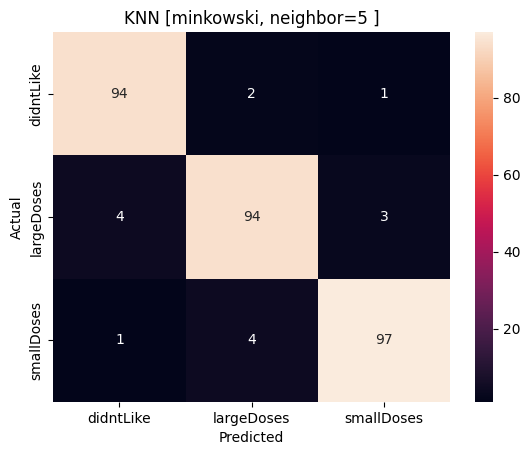

In [10]:
conf_mat=pd.crosstab(y_test, y_pred, rownames=['Actual'],colnames=['Predicted'])
sns.heatmap(conf_mat, annot=True).set(title='KNN [minkowski, neighbor=5 ]')

In [11]:
models = pd.DataFrame ( {
'n_neighbors': ['1', '2','3','4','5'],
'Accuracy Score':
[results[0],results[1], results[2],results[3],results[4]]})
models.sort_values (by='Accuracy Score')
print (models.to_string(index=False))

n_neighbors  Accuracy Score
          1        0.930000
          2        0.923333
          3        0.936667
          4        0.946667
          5        0.950000


In [12]:
data = {
    'Brightness': [40, 50, 60, 10, 70, 60, 25],
    'Saturation': [20, 50, 90, 25, 70, 10, 80],
    'Class': ['Red', 'Blue', 'Blue', 'Red', 'Blue', 'Red', 'Blue']
}

df = pd.DataFrame(data)

df

,Brightness,Saturation,Class
0,40,20,Red
1,50,50,Blue
2,60,90,Blue
3,10,25,Red
4,70,70,Blue
5,60,10,Red
6,25,80,Blue


In [14]:
x=df.iloc[:, :-1].values
y=df.iloc[:, -1].values

In [18]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3, random_state=0, stratify=y)

In [19]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [20]:
results=[]
for i in range(1, len(x_train) + 1):
  model = KNeighborsClassifier(n_neighbors=i, metric='minkowski', p=2)
  model.fit(x_train, y_train)
  y_pred=model.predict(x_test)
  Accuracy_score=metrics.accuracy_score(y_test, y_pred)
  results.append (Accuracy_score)
print('KNN [ minkowski ]')
print('for n neighbor=' + str(i) + ' : ')
conf_mat=metrics.confusion_matrix(y_test, y_pred)
print('\n Confusion Matrix: ', conf_mat)
print('Accuracy Score : ', Accuracy_score)
print('Accuracy in Percentage : ',
int (Accuracy_score*100),'%')
print('\n',classification_report(y_test, y_pred))
print(results)

KNN [ minkowski ]
for n neighbor=4 : 

 Confusion Matrix:  [[2 0]
 [1 0]]
Accuracy Score :  0.6666666666666666
Accuracy in Percentage :  66 %

               precision    recall  f1-score   support

        Blue       0.67      1.00      0.80         2
         Red       0.00      0.00      0.00         1

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3

[0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[Text(0.5, 1.0, 'KNN [minkowski, neighbor=5 ]')]

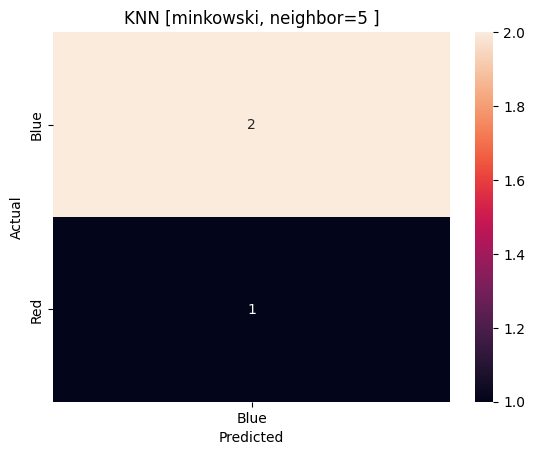

In [22]:
conf_mat=pd.crosstab(y_test, y_pred, rownames=['Actual'],colnames=['Predicted'])
sns.heatmap(conf_mat, annot=True).set(title='KNN [minkowski, neighbor=5 ]')